N = 509 | Total median = 5860.1 | IQR = 1857.6


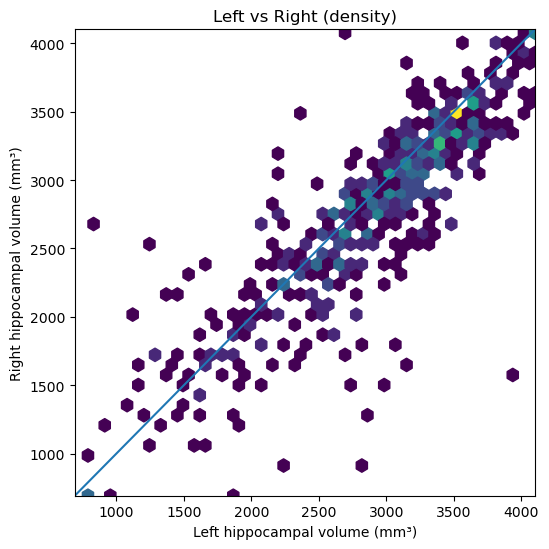

Saved: C:\Users\konyang\hippo_figs_pretty\hexbin_L_vs_R.png


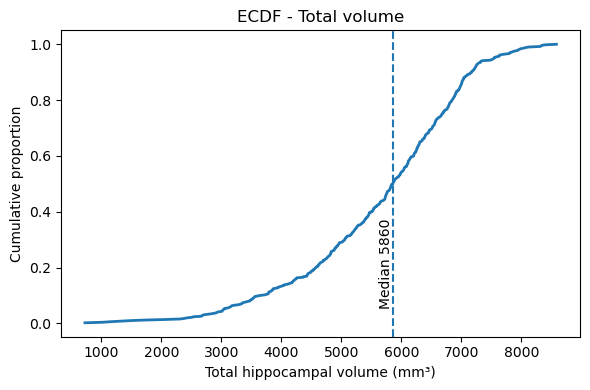

Saved: C:\Users\konyang\hippo_figs_pretty\ecdf_total.png


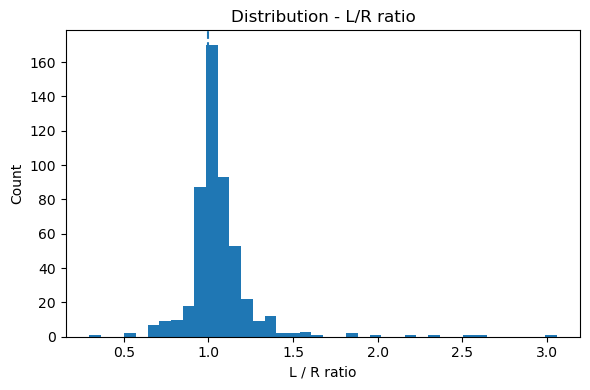

Saved: C:\Users\konyang\hippo_figs_pretty\dist_lr_ratio.png


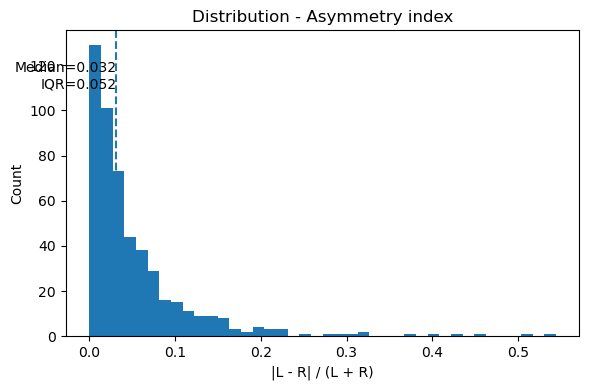

Saved: C:\Users\konyang\hippo_figs_pretty\dist_asym.png


In [2]:
data_path = r"D:/ADNI/feature/hippo_features_all.csv"
outdir = "./hippo_figs_pretty"
MIN_VOL = 200
CLIP_PCT = (1, 99)


import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
Path(outdir).mkdir(parents=True, exist_ok=True)

p = Path(data_path)
if p.suffix.lower() in [".xlsx", ".xls"]:
    df = pd.read_excel(p, engine="openpyxl")
elif p.suffix.lower() == ".csv":
    try: df = pd.read_csv(p, encoding="utf-8-sig")
    except UnicodeDecodeError: df = pd.read_csv(p, encoding="cp949")
else:
    raise ValueError("지원 확장자: .xlsx/.xls/.csv")

cols_lower = {c: str(c).lower() for c in df.columns}
def pick_col(keys):
    for c, lc in cols_lower.items():
        if all(k in lc for k in keys): return c
    return None

cL  = pick_col(["left","vol"])  or pick_col(["l","vol"])  or pick_col(["left","mm"])
cR  = pick_col(["right","vol"]) or pick_col(["r","vol"])  or pick_col(["right","mm"])
cT  = pick_col(["total","vol"]) or pick_col(["sum","vol"])
cDX = pick_col(["diagnosis"]) or pick_col(["dx"]) or pick_col(["group"]) or pick_col(["label"])
assert cL and cR, f"Left/Right 컬럼 매핑 실패. columns={list(df.columns)}"

L_raw = pd.to_numeric(df[cL], errors="coerce").astype(float)
R_raw = pd.to_numeric(df[cR], errors="coerce").astype(float)

mask = (
    L_raw.notna() & R_raw.notna() &
    np.isfinite(L_raw) & np.isfinite(R_raw) &
    (L_raw > MIN_VOL) & (R_raw > MIN_VOL)
)
L = L_raw[mask].copy()
R = R_raw[mask].copy()

def clip_p(s, pct_pair):
    if pct_pair and len(s) > 10:
        lo, hi = np.percentile(s, pct_pair)
        return s.clip(lo, hi)
    return s

L = clip_p(L, CLIP_PCT)
R = clip_p(R, CLIP_PCT)

T   = (pd.to_numeric(df[cT], errors="coerce")[mask].astype(float)
       if cT else (L + R))
LR  = L / R
ASY = (L - R).abs() / (L + R)

print("N =", len(T),
      "| Total median =", np.median(T).round(1),
      "| IQR =", (np.percentile(T,75)-np.percentile(T,25)).round(1))

def save_show(path):
    plt.tight_layout(); plt.savefig(path, bbox_inches="tight", dpi=180); plt.show()
    print("Saved:", Path(path).resolve())

plt.figure(figsize=(5.6,5.6))
plt.hexbin(L, R, gridsize=40, mincnt=1)
lims = [min(L.min(), R.min()), max(L.max(), R.max())]
plt.plot(lims, lims)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Left hippocampal volume (mm³)")
plt.ylabel("Right hippocampal volume (mm³)")
plt.title("Left vs Right (density)")
save_show(f"{outdir}/hexbin_L_vs_R.png")

def ecdf(x):
    x = np.sort(np.asarray(x)); y = np.arange(1, len(x)+1)/len(x); return x, y
x, y = ecdf(T)
plt.figure(figsize=(6,4))
plt.plot(x, y, lw=2)
med = np.median(T)
plt.axvline(med, ls="--")
plt.text(med, 0.05, f"Median {med:.0f}", rotation=90, va="bottom", ha="right")
plt.xlabel("Total hippocampal volume (mm³)"); plt.ylabel("Cumulative proportion")
plt.title("ECDF - Total volume")
save_show(f"{outdir}/ecdf_total.png")

plt.figure(figsize=(6,4))
plt.hist(LR, bins=40)
plt.axvline(1.0, ls="--")
plt.xlabel("L / R ratio"); plt.ylabel("Count")
plt.title("Distribution - L/R ratio")
save_show(f"{outdir}/dist_lr_ratio.png")

plt.figure(figsize=(6,4))
plt.hist(ASY, bins=40)
med_asym = np.median(ASY); iqr_asym = np.percentile(ASY,75)-np.percentile(ASY,25)
plt.axvline(med_asym, ls="--")
plt.text(med_asym, plt.ylim()[1]*0.9, f"Median={med_asym:.3f}\nIQR={iqr_asym:.3f}",
         ha="right", va="top")
plt.xlabel("|L - R| / (L + R)"); plt.ylabel("Count")
plt.title("Distribution - Asymmetry index")
save_show(f"{outdir}/dist_asym.png")

if cDX:
    DX = df[cDX][mask].astype(str)
    groups = sorted(DX.dropna().unique())
    data = [T[DX==g].values for g in groups if (DX==g).sum()>0]
    if len(data) >= 2:
        plt.figure(figsize=(7,4))
        plt.boxplot(data, labels=[g for g in groups if (DX==g).sum()>0], showfliers=False)
        plt.ylabel("Total volume (mm³)")
        plt.title("Group comparison - Total volume")
        save_show(f"{outdir}/box_total_by_group.png")